In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import urllib.request
import json
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
url = "https://www.gutenberg.org/cache/epub/1661/pg1661.txt"
req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})

with urllib.request.urlopen(req) as response:
    raw_text = response.read().decode("utf-8")

# Strip the Project Gutenberg header and footer
start_idx = raw_text.find("I. A SCANDAL IN BOHEMIA")
end_idx = raw_text.find("End of the Project Gutenberg")
text = raw_text[start_idx:end_idx].strip()

print(f"Loaded {len(text)} characters of normal English text.")
print(f"Sample preview:\n{text[:200]}")

Loaded 592375 characters of normal English text.
Sample preview:
I. A SCANDAL IN BOHEMIA


I.

To Sherlock Holmes she is always _the_ woman. I have seldom heard him
mention her under any other name. In his eyes she eclipses and
predominates the whole of her 


In [3]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

char_to_id = {ch: i for i, ch in enumerate(chars)}
id_to_char = {i: ch for i, ch in enumerate(chars)}

def encode(string):
    return [char_to_id[ch] for ch in string]

def decode(indices):
    return "".join([id_to_char[idx] for idx in indices])

# Convert entire book into a single tensor
data = torch.tensor(encode(text), dtype=torch.long, device=device)
print(f"Vocab size: {vocab_size} unique characters")

Vocab size: 97 unique characters


In [4]:
def get_batch(batch_size=16, seq_len=256):
    # Grab longer text chunks so the window has room to slide
    max_start = len(data) - seq_len
    start_indices = torch.randint(0, max_start, (batch_size,))
    
    sequences = torch.stack([data[i:i + seq_len] for i in start_indices])
    return sequences

# Diagnostic Functions

In [5]:
def inspect_window(data):
    if data['window_idx'] == 0:
        raw_loss = data['raw_loss']
        slot_losses = raw_loss.mean(dim=0).tolist()
        formatted = [round(l, 2) for l in slot_losses]
        print(f"Slot losses: {formatted}")

        # 1. Decode the preceding context window that the model just read
        input_ids = data['input'][0].tolist()
        context_text = decode(input_ids)

        # 2. Decode the highest probability token for each future slot
        pred_ids = torch.argmax(data['predictions'][0], dim=-1).tolist()
        pred_text = decode(pred_ids)

        # 3. Decode the actual ground truth tokens that came next
        target_ids = data['targets'][0].tolist()
        target_text = decode(target_ids)

        # 4. Print the trailing part of context along with the predictions
        # Slicing the last 48 characters keeps the output easy to read in the terminal
        print(f"Context:        {repr(context_text)}")
        print(f"Pred:           {repr(pred_text)}")
        print(f"Target:         {repr(target_text)}")

In [6]:
# Streaming callback for real-time generation preview
def stream_character(data):
    char = decode(data['new_tokens'][0].tolist())
    
    # Swap raw line breaks with visible text markers
    safe_char = char.replace('\n', '\\n').replace('\r', '\\r')
    
    print(safe_char, end="", flush=True)

In [7]:
# Class to compare model gradients. (Class so it doesnt need to write to disk every step)
class DiagnosticTracker:
    def __init__(self, vocab, model_name="model"):
        self.vocab = vocab
        self.save_path = "training_artifacts/" + model_name + "_diagnostics.json"
        self.records = []

    def _decode(self, token_ids):
        if self.vocab is None:
            return str(token_ids)
        
        if isinstance(self.vocab, (list, str)):
            return "".join([self.vocab[i] if 0 <= i < len(self.vocab) else "?" for i in token_ids])
        
        if isinstance(self.vocab, dict):
            return "".join([self.vocab.get(i, "?") for i in token_ids])
        
        return str(token_ids)

    def __call__(self, data):
        window_idx = data.get('window_idx', 0)
        model = data.get('model', None)
        raw_loss = data['raw_loss']
        slot_losses = [round(float(val), 4) for val in raw_loss.mean(dim=0).tolist()]

        context_ids = data['input'][0].tolist()
        pred_ids = torch.argmax(data['predictions'][0], dim=-1).tolist()
        target_ids = data['targets'][0].tolist()

        context_text = self._decode(context_ids)
        pred_text = self._decode(pred_ids)
        target_text = self._decode(target_ids)

        # Print the first window
        if window_idx == 0:
            print(f"Slot losses: {slot_losses}")
            print(f"Context:     {repr(context_text[-48:])}")
            print(f"Pred:        {repr(pred_text)}")
            print(f"Target:      {repr(target_text)} \n")

        param_grads = {}
        layer_group_grads = {}

        if model is not None:
            for name, param in model.named_parameters():
                if param.grad is not None:
                    norm_val = round(float(param.grad.norm().item()), 6)
                    param_grads[name] = norm_val

                    for layer_idx in range(getattr(model, "num_layers", 4)):
                        if f"layers.{layer_idx}" in name or f"encoder.layers.{layer_idx}" in name:
                            key = f"layer_{layer_idx}"
                            current_sq = layer_group_grads.get(key, 0.0) ** 2
                            layer_group_grads[key] = round((current_sq + norm_val ** 2) ** 0.5, 6)

        self.records.append({
            'window_idx': window_idx,
            'step_loss': round(float(data['step_loss']), 4),
            'slot_losses': slot_losses,
            'context': context_text[-48:],
            'pred': pred_text,
            'target': target_text,
            'layer_summary': layer_group_grads,
            'param_gradients': param_grads
        })

    def save(self, custom_path=None):
        target_file = custom_path if custom_path is not None else self.save_path
        os.makedirs(os.path.dirname(target_file), exist_ok=True)
        with open(target_file, "w") as f:
            json.dump(self.records, f, indent=2)
        print(f"Saved diagnostic telemetry to {target_file}")

## Model Configuration

In [8]:
# Shared Model Configurations
config = {
    "hidden_dim": 256,
    "num_heads": 8,
    "num_layers": 4
}

# Sliding Window Configurations
window_config = {
    "window_size": 64,
    "num_windows": 4,
    "stride": 1,
    "sweep_iters": 2,
    "layer_iters": 2
}

# Minimum tokens needed to feed all windows plus the 1-token target shift
seq_len = window_config["window_size"] + 1 + (window_config["num_windows"] - 1) * window_config["stride"]

# Training config
batch_size = 64
num_steps = 100
learning_rate = 0.001

## FLB Model

In [9]:
from FLB_model.FLB_Model import FLB_Model

# Initialize model without hardcoded stride or prediction horizons
FLB_model = torch.compile(FLB_Model(
    vocab_size=vocab_size,
    hidden_dim=config["hidden_dim"],
    num_heads=config["num_heads"],
    num_layers=config["num_layers"],
    sweep_iters=window_config["sweep_iters"],
    layer_iters=window_config["layer_iters"],
    window_size=window_config["window_size"]
).to(device))

# Initialize the diagnostic tracker to monitor training progress
flb_tracker = DiagnosticTracker(vocab=chars, model_name="flb")

optimizer = optim.AdamW(FLB_model.parameters(), lr=learning_rate)

for step in range(1, num_steps + 1):
    # Pass the calculated seq_len variable directly
    batch = get_batch(batch_size=batch_size, seq_len=seq_len)

    # train_model handles window slicing and per-window weight updates
    avg_loss, _ = FLB_model.train_model(
        sequence=batch,
        optimizer=optimizer,
        stride=window_config["stride"],
        on_window= flb_tracker
    )

    if step % 100 == 0 or step == 1:
        print(f"Step {step:04d} | Window Avg Loss {avg_loss:.4f}")
        
        prompt_text = "The man was "
        prompt_tokens = torch.tensor([encode(prompt_text)], dtype=torch.long, device=device)
        
        print(f"Sample: '{prompt_text}", end="", flush=True)
        FLB_model.generate(
            prompt=prompt_tokens,
            num_tokens=64,
            temperature=0.8,
            on_step=stream_character
        )
        print("'\n")

# Write diagnostic telemetry to training_artifacts/flb_diagnostics.json
flb_tracker.save()

Slot losses: [4.7627, 4.8989, 4.775, 4.8086, 4.7628, 4.8344, 4.8206, 4.627, 4.6469, 4.6271, 4.7319, 4.7031, 4.8409, 4.7213, 4.7946, 4.74, 4.6781, 4.6902, 4.6524, 4.6865, 4.8047, 4.7203, 4.7252, 4.7097, 4.8132, 4.7119, 4.7537, 4.7459, 4.6693, 4.6913, 4.665, 4.8161, 4.7422, 4.8172, 4.7555, 4.7606, 4.8707, 4.8052, 4.8337, 4.9027, 4.7358, 4.7371, 4.8733, 4.6927, 4.6602, 4.7871, 4.6124, 4.8338, 4.7094, 4.7016, 4.5366, 4.8251, 4.7061, 4.8506, 4.843, 4.8417, 4.7415, 4.8005, 4.8075, 4.7566, 4.681, 4.7878, 4.8684, 4.7464]
Context:     'ow of sleepers,\r\nholding my breath to keep out t'
Pred:        '00uUxFpU5fOwOpUEfqU3oU)é0p30E)ifUFSOH9u4U.0UwE0’xFUxfUo003U3OxUx'
Target:      'en the double row of sleepers,\r\nholding my breath to keep out th' 

Step 0001 | Window Avg Loss 3.7238
Sample: 'The man was drtaycthou athtilese_ns otolrearottidheta4,inok+t d o+t tolfGtht'

Slot losses: [3.065, 3.0254, 3.1015, 3.302, 2.7807, 3.0365, 3.0579, 2.9698, 2.8748, 2.727, 2.982, 2.8852, 3.0814, 2.8587, 2.9548

## Baseline Transformer Model

In [10]:
from Baselines.Transformer import BaselineTransformer
from Baselines.training import train_baseline_model

# Initialize compute-matched layer baseline
baseline_model = BaselineTransformer(
    vocab_size=vocab_size,
    hidden_dim=config["hidden_dim"],
    num_heads=config["num_heads"],
    num_layers=config["num_layers"],
    window_size=window_config["window_size"]
).to(device)

# Setup tracker and optimizer
baseline_tracker = DiagnosticTracker(vocab=chars, model_name="transformer_baseline")
baseline_optimizer = torch.optim.AdamW(baseline_model.parameters(), lr=learning_rate)

# Execute training loop
train_baseline_model(
    model=baseline_model,
    optimizer=baseline_optimizer,
    get_batch_fn=get_batch,
    batch_size=batch_size,
    seq_len=seq_len,
    window_config=window_config,
    vocab_size=vocab_size,
    num_steps=num_steps,
    tracker=baseline_tracker
)

Slot losses: [4.7657, 4.6282, 4.7317, 4.6588, 4.9171, 4.7306, 4.9866, 4.6333, 4.7463, 4.6449, 4.6229, 4.6772, 5.1624, 4.7531, 4.6448, 4.7114, 4.9508, 4.62, 4.8246, 4.7899, 4.6136, 4.6535, 4.7628, 4.8158, 4.6442, 4.4556, 4.7575, 4.6775, 4.7414, 4.5554, 4.7934, 4.6539, 4.8347, 4.8005, 4.6203, 4.6618, 4.6697, 4.5022, 4.7343, 4.776, 4.8244, 4.6836, 4.679, 4.7388, 4.6728, 4.8485, 4.9435, 4.9184, 4.7625, 4.7432, 4.6706, 4.6473, 4.7135, 4.7386, 4.8027, 4.8093, 4.6164, 4.8621, 4.9906, 4.8154, 4.9946, 4.577, 4.9334, 4.561]
Context:     'ateful for what you have done. Your skill has in'
Pred:        'vX!pZUXcs!£pP3&+8ié4hF—&£yr“x8mFâr•s2 PéX6k8--pdrmoTBl8Z&1R8—F8&'
Target:      'ot find me ungrateful for what you have done. Your skill has ind' 

Step 0001 | Window Avg Loss 3.9223
Slot losses: [3.1281, 3.2183, 3.2489, 3.1684, 3.1927, 3.3029, 3.1837, 3.2888, 2.9807, 3.1537, 3.1465, 3.2794, 3.2565, 3.2767, 3.1076, 3.2061, 3.3273, 3.1806, 3.2471, 2.9458, 3.1687, 2.9091, 3.3561, 2.8812, 3.2056, 3.070

## Baseline Layer Equivalent Transformer Model

In [11]:
from Baselines.Transformer import BaselineTransformer
from Baselines.training import train_baseline_model

# Initialize compute-matched layer baseline
baseline_equivalent_layer_model = BaselineTransformer(
    vocab_size=vocab_size,
    hidden_dim=config["hidden_dim"],
    num_heads=config["num_heads"],
    num_layers=config["num_layers"] * window_config["sweep_iters"] * window_config["layer_iters"],
    window_size=window_config["window_size"]
).to(device)

# Setup tracker and optimizer
baseline_tracker = DiagnosticTracker(vocab=chars, model_name="equivalent_layer_transformer")
baseline_optimizer = torch.optim.AdamW(baseline_equivalent_layer_model.parameters(), lr=learning_rate)

# Execute training loop
train_baseline_model(
    model=baseline_equivalent_layer_model,
    optimizer=baseline_optimizer,
    get_batch_fn=get_batch,
    batch_size=batch_size,
    seq_len=seq_len,
    window_config=window_config,
    vocab_size=vocab_size,
    num_steps=num_steps,
    tracker=baseline_tracker
)

Slot losses: [4.7348, 4.6587, 4.7009, 4.7215, 4.6128, 4.6341, 4.7566, 4.6292, 4.5106, 4.4119, 4.6521, 4.5303, 4.6286, 4.5968, 4.6856, 4.6671, 4.5875, 4.7167, 4.6122, 4.6456, 4.4652, 4.3927, 4.5809, 4.6693, 4.6318, 4.6046, 4.5874, 4.6749, 4.4015, 4.7317, 4.6144, 4.5475, 4.719, 4.586, 4.6551, 4.6045, 4.4328, 4.5205, 4.6059, 4.6114, 4.4916, 4.5723, 4.6445, 4.6556, 4.5979, 4.532, 4.5888, 4.7096, 4.6911, 4.4713, 4.4711, 4.5586, 4.5232, 4.6947, 4.6344, 4.6662, 4.6855, 4.5838, 4.4748, 4.583, 4.6222, 4.4765, 4.5125, 4.6748]
Context:     'hen I\r\npay good money for a good article there s'
Pred:        'f7q“:(: “:f“C1“ ::“7*“c7“*C“zC\rC“F5C*k8“**v*qCr8*8 (C1C“r (w: z '
Target:      'ered as I am. When I\r\npay good money for a good article there sh' 

Step 0001 | Window Avg Loss 3.8126
Slot losses: [3.3947, 3.1861, 3.2809, 3.2611, 3.3667, 3.4168, 3.1143, 3.218, 3.3904, 3.2627, 3.2421, 3.1287, 3.1871, 3.376, 3.2041, 3.2615, 3.1348, 3.3959, 3.2815, 3.2756, 3.4507, 3.2044, 3.2182, 3.0261, 3.3088, 

# Compare Models

In [12]:
from plotting import load_diagnostics, plot_loss_trajectory, plot_position_error_profile, plot_window_progression, plot_gradient_flow, plot_layer_gradients, plot_diagnostic_dashboard

Comparison dashboard saved to training_artifacts/diagnostic_comparison.png


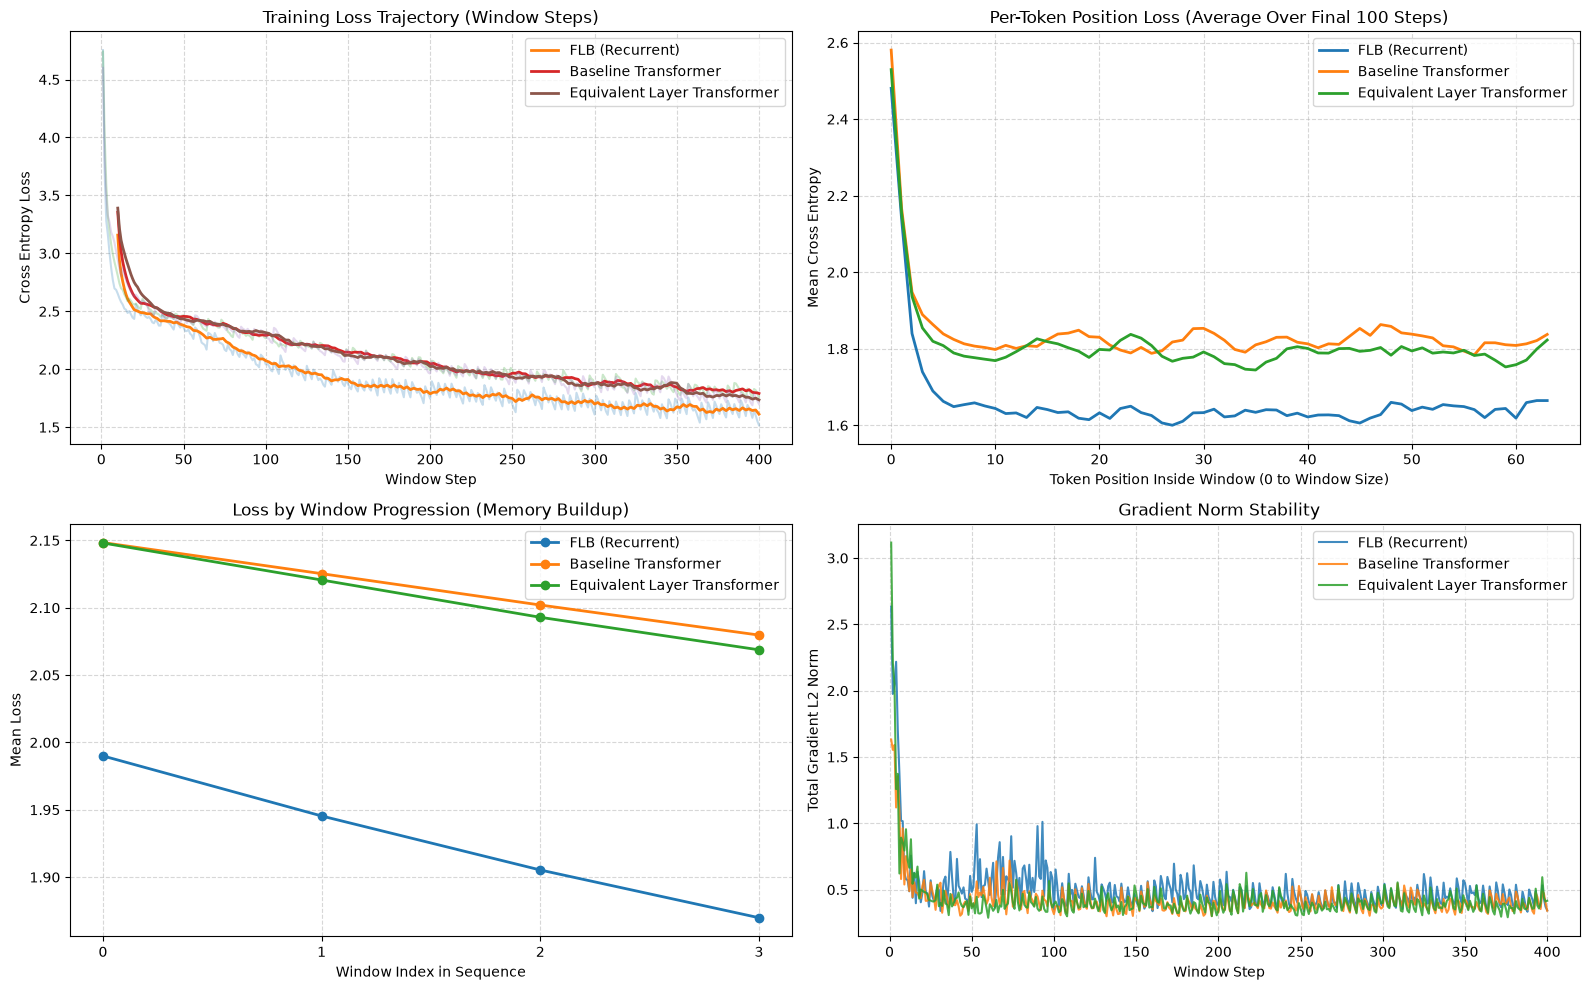

In [14]:
runs = {
    "FLB (Recurrent)": "training_artifacts/flb_diagnostics.json",
    "Baseline Transformer": "training_artifacts/transformer_baseline_diagnostics.json",
    "Equivalent Layer Transformer": "training_artifacts/equivalent_layer_transformer_diagnostics.json"
}

plot_diagnostic_dashboard(runs, save_path="training_artifacts/diagnostic_comparison.png")

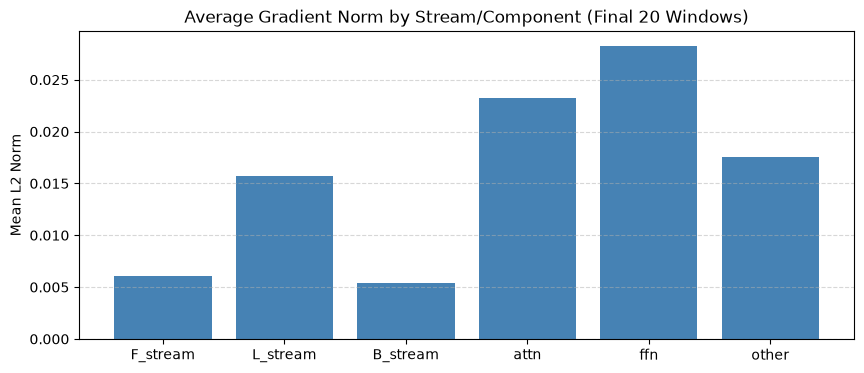

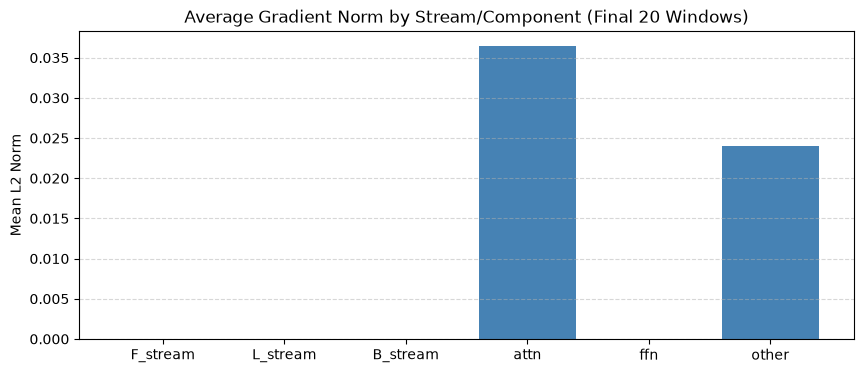

In [ ]:
plot_layer_gradients("training_artifacts/flb_diagnostics.json", ax=None, last_n=20)
plot_layer_gradients("training_artifacts/baseline_diagnostics.json", ax=None, last_n=20)
plot_layer_gradients("training_artifacts/equivalent_layer_transformer_diagnostics.json", ax=None, last_n=20)